#       Data Analysis Project

## importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc

# Load dataset
df = pd.read_csv("Superstore Marketing Campaign Dataset.csv")

# View basic info
df.head()

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/14,0,189,...,111,189,218,1,4,4,6,1,1,0
1,1,1961,Graduation,Single,57091.0,0,0,6/15/14,0,464,...,7,0,37,1,7,3,7,5,1,0
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/14,0,134,...,15,2,30,1,3,2,5,2,0,0
3,1386,1967,Graduation,Together,32474.0,1,1,11/5/14,0,10,...,0,0,0,1,1,0,2,7,0,0
4,5371,1989,Graduation,Single,21474.0,1,0,8/4/14,0,6,...,11,0,34,2,3,1,2,7,1,0


## Understanding Dataset

## Column 
 **Id**          Unique customer identifier
 
 **Year_Birth**      Year of birth (used to derive customer age)
 
 **Education**       Education level (e.g. Basic, Graduation, Master, PhD)
 
 **Marital_Status**  Marital status (e.g. Single, Married, Together, Absurd, Widow)
 
 **Income**          Yearly household income in monetary units
 
 **Kidhome**         Number of children in the household
 
**Teenhome**         Number of teenagers in the household 

**Dt_Customer**        Date the customer first enrolled with the company 

**Recency**            Number of days since the customer’s last purchase 

**MntWines**          Amount spent on wine products in the last two years

**MntFruits**         Amount spent on fruit products in the last two years           

**MntMeatProducts**       Amount spent on meat products in the last two years

**MntFishProducts**	     Amount spent on fish products in the last two years

**MntSweetProducts**	 Amount spent on sweet products in the last two years

**MntGoldProds**	     Amount spent on gold products in the last two years

**NumDealsPurchases**	 Number of purchases made with a discount

**NumWebPurchases**	     Number of purchases made via the website

**NumCatalogPurchases**	 Number of purchases made via catalog

**NumStorePurchases**	 Number of purchases made in physical stores

**NumWebVisitsMonth**	 Number of visits to the company’s website in the last month

**Complain**	         1 if the customer complained in the last two years, else 0

**Response**      	     Target variable: 1 if the customer accepted the gold offer, 0 otherwise

## Check Data Structure

In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

,Id,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.149107,0.009375
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.356274,0.096391
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000


## Handle Missing Values

In [3]:
# Check missing values
df.isnull().sum()

Id                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Response                0
Complain                0
dtype: int64

In [4]:
zero_count = (df['Income'] == 0).sum()
print(zero_count)

0


## Fill missing Income with median:

In [5]:
df['Income'].fillna(df['Income'].median(), inplace=True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27432\1959487941.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(df['Income'].median(), inplace=True)


## Convert Date Column

In [6]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27432\177162232.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])


## Compute Age

In [7]:
current_year = 2026
df['Age'] = current_year - df['Year_Birth']

## checking outliers of Age

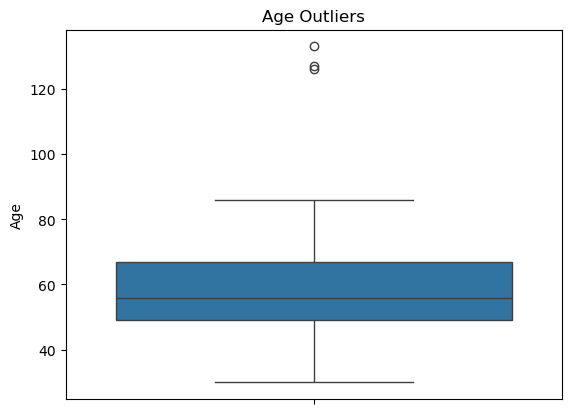

<Figure size 400x500 with 0 Axes>

In [8]:
sns.boxplot(df['Age'])
plt.title("Age Outliers")
plt.figure(figsize=(4,5))
plt.show()

## Removing outliers from Age

In [9]:
df=df[df['Age']<90]

## Customer Tenure

In [10]:
df['Customer_Tenure'] = (pd.to_datetime("today") - df['Dt_Customer']).dt.days

## Total Spending

In [11]:
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
              'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

df['Total_Spend'] = df[spend_cols].sum(axis=1)

## Category Breadth

In [12]:
df['Category_Breadth'] = (df[spend_cols] > 0).sum(axis=1)

## Engagement Features

In [13]:
df['Total_Purchases'] = df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases']

df['Web_Purchase_Ratio'] = df['NumWebPurchases'] / (df['Total_Purchases'] + 1)

## Convert string into float

In [14]:
# 2. Define the rank/order for the strings
# We map them to floats based on the level of education
education_mapping = {
    'Basic': 1.0,
    '2n Cycle': 2.0,
    'Graduation': 3.0,
    'Master': 4.0,
    'PhD': 5.0
}
# 3. Apply the mapping to create a new float column
df['Education_Float'] = df['Education'].map(education_mapping)

## Preprocessed data

In [15]:
df.head()

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,Response,Complain,Age,Customer_Tenure,Total_Spend,Category_Breadth,Total_Purchases,Web_Purchase_Ratio,Education_Float
0,1826,1970,Graduation,Divorced,84835.0,0,0,2014-06-16,0,189,...,1,1,0,56,4341,1190,6,14,0.266667,3.0
1,1,1961,Graduation,Single,57091.0,0,0,2014-06-15,0,464,...,5,1,0,65,4342,577,5,17,0.388889,3.0
2,10476,1958,Graduation,Married,67267.0,0,1,2014-05-13,0,134,...,2,0,0,68,4375,251,6,10,0.272727,3.0
3,1386,1967,Graduation,Together,32474.0,1,1,2014-11-05,0,10,...,7,0,0,59,4199,11,2,3,0.250000,3.0
4,5371,1989,Graduation,Single,21474.0,1,0,2014-08-04,0,6,...,7,1,0,37,4292,91,5,6,0.428571,3.0


# Exploratory Analysis

## Histgram

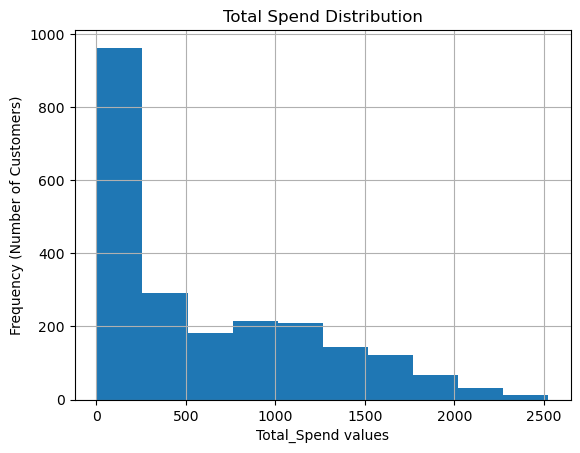

In [16]:
df['Total_Spend'].hist()
plt.title("Total Spend Distribution")
plt.xlabel('Total_Spend values')
plt.ylabel('Frequency (Number of Customers)')
plt.show()

## Boxplot

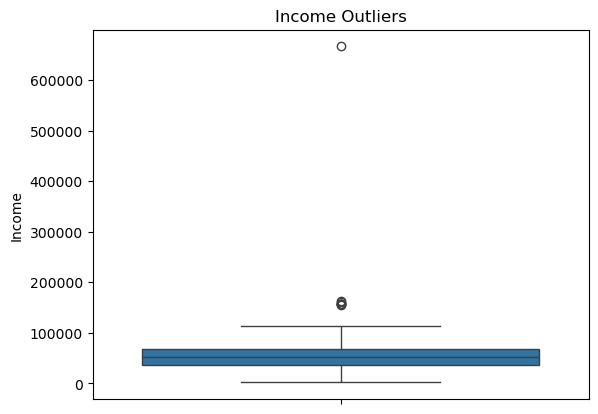

<Figure size 400x500 with 0 Axes>

In [17]:
sns.boxplot(df['Income'])
plt.title("Income Outliers")
plt.figure(figsize=(4,5))
plt.show()

## Correlation Matrix

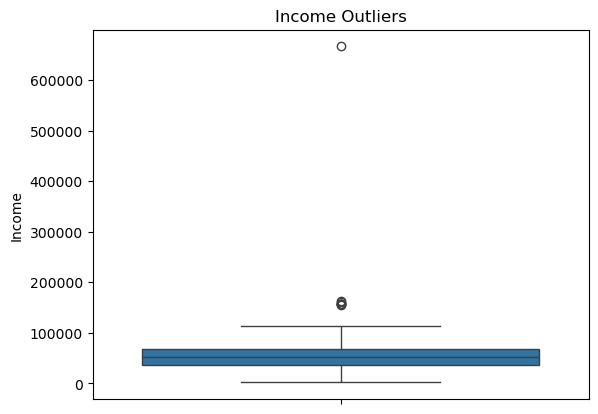

<Figure size 400x500 with 0 Axes>

In [18]:
sns.boxplot(df['Income'])
plt.title("Income Outliers")
plt.figure(figsize=(4,5))
plt.show()

## Pairplot

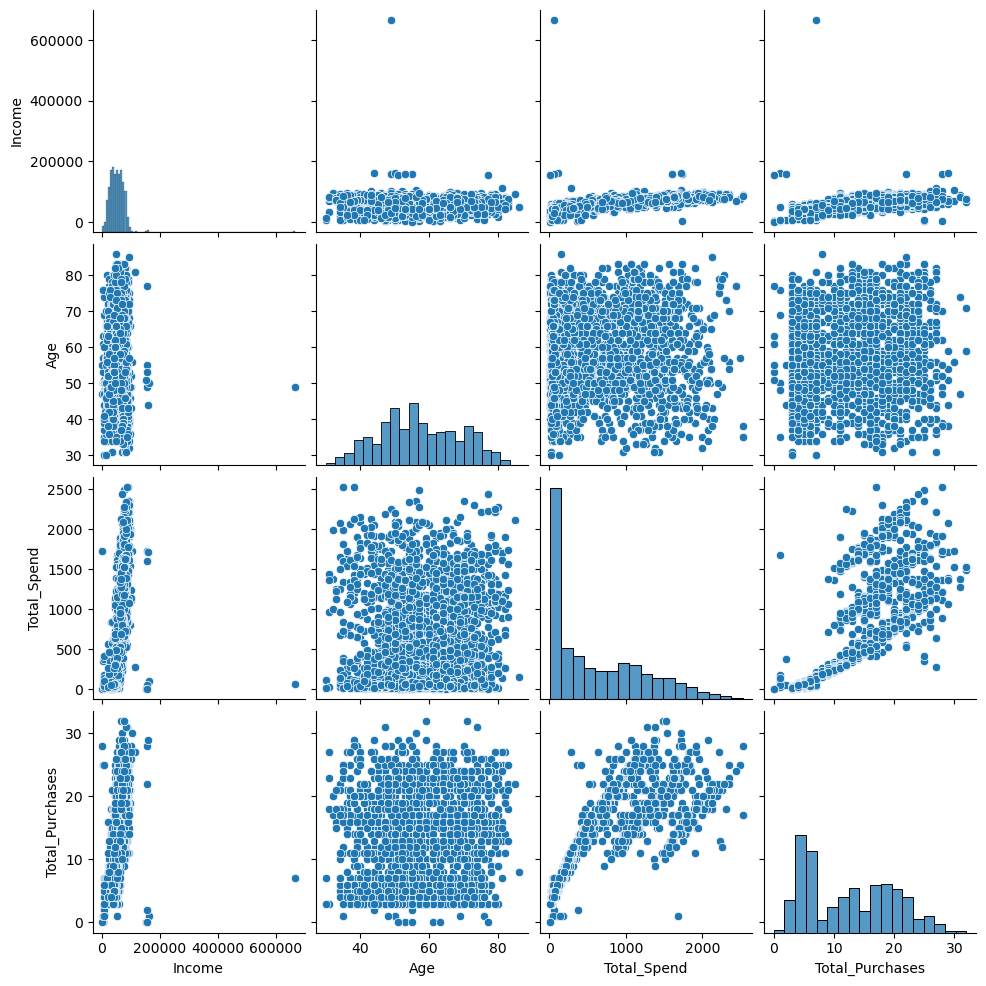

In [19]:
sns.pairplot(df[['Income', 'Age', 'Total_Spend', 'Total_Purchases']])
plt.show()

## Customer Segmentation (Basic)

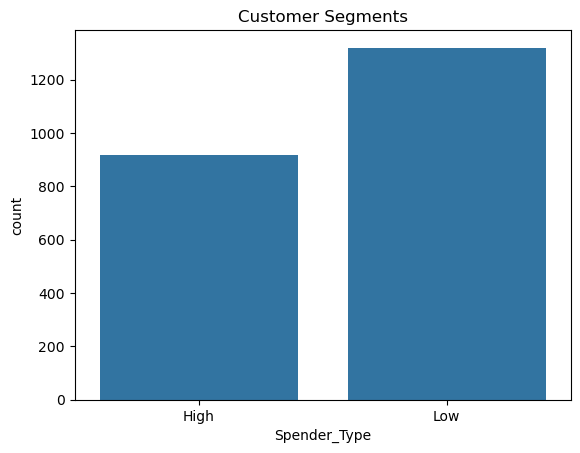

In [20]:
# High vs Low spenders
df['Spender_Type'] = np.where(df['Total_Spend'] > df['Total_Spend'].mean(),
                             'High', 'Low')

sns.countplot(x='Spender_Type', data=df)
plt.title("Customer Segments")
plt.show()

# STATISTICAL ANALYSIS

# T-Test (Compare 2 Groups)

### Test: Income difference between High and Low spenders

### Null Hypothesis (H₀)

👉 There is no significant difference in income between the two groups.

### Alternative Hypothesis (H₁)

👉 There is a significant difference in income between the two groups.

In [21]:
from scipy import stats

In [22]:
# Separate groups
high = df[df['Spender_Type'] == 'High']['Income']
low = df[df['Spender_Type'] == 'Low']['Income']

# Perform T-test
t_stat, p_value = stats.ttest_ind(high, low)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: 37.25111970143844
P-Value: 1.1003265652687734e-236


### no significant difference

# ANOVA Test

## Null Hypothesis (H₀)

👉 All group means are equal (no difference in spending across education levels)

👉 In your case:
Mean spending of Graduation = PhD = Master = etc.

## Alternative Hypothesis (H₁)

👉 At least one group mean is different

In [23]:
from scipy import stats

# Group data
groups = df.groupby('Education')['Total_Spend'].apply(list)

# ANOVA test
f_stat, p_value = stats.f_oneway(*groups)

print("F-Statistic:", f_stat)
print("P-Value:", p_value)

F-Statistic: 13.598672667298619
P-Value: 5.889795808232043e-11


## Significant Difference

# RELATIONSHIP TEST (CHI-SQUARE)
## Relationship between Education and Response

## Null Hypothesis (H₀)

👉 There is no relationship between Education and Response

## Alternative Hypothesis (H₁)

👉 There is a relationship between Education and Response

In [24]:
import pandas as pd
from scipy.stats import chi2_contingency

# Create contingency table
table = pd.crosstab(df['Education'], df['Response'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(table)

print("Chi2:", chi2)
print("P-Value:", p)

Chi2: 23.052287932633178
P-Value: 0.00012361656648398502


## significant diffrence

# MODELING (PREDICT RESPONSE)

## Prepare Data

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Convert categorical to numeric
le = LabelEncoder()
df['Education'] = le.fit_transform(df['Education'])
df['Marital_Status'] = le.fit_transform(df['Marital_Status'])

# Features & target
X = df[['Income', 'Age', 'Total_Spend', 'Total_Purchases']]
y = df['Response']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## Logistic Regression

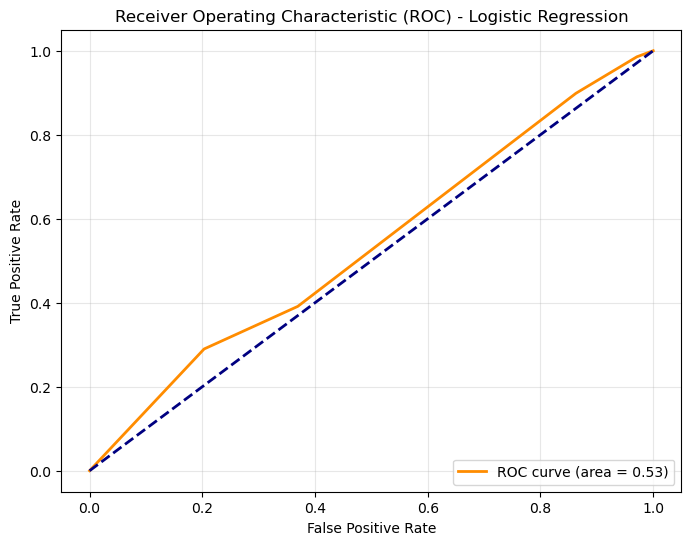

Model AUC Score: 0.5350


In [26]:

# Selecting key features for the model
features = ['Education_Float']
X = df[features]
y = df['Response']

# Scale the features (Important for gradient-based models like Logistic Regression)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#  Split the data into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

#  Initialize and Train the Logistic Regression Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Evaluation - Calculating the ROC Curve
y_pred_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plotting the Graph
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Logistic Regression')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"Model AUC Score: {roc_auc:.4f}")

## Support Vector Machines (SVM) Overview

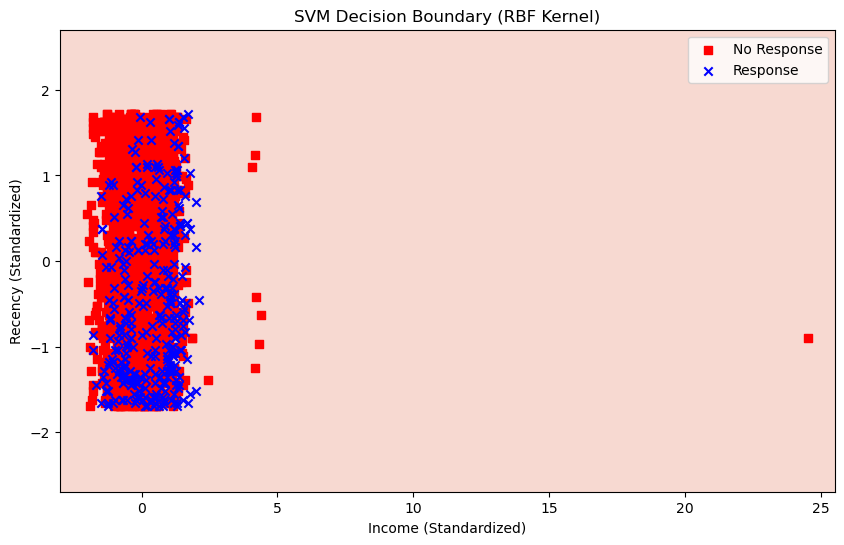

In [27]:
# Select Features & Scale
X = df[['Income', 'Recency']].values
y = df['Response'].values
scaler = StandardScaler() # Scaling is required for SVM[cite: 1]
X_scaled = scaler.fit_transform(X)

# Train Model
svm = SVC(kernel='rbf', gamma=0.5, C=1.0)
svm.fit(X_scaled, y)

# Create Plotting Mesh
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict and Plot
Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu') # Decision regions
plt.scatter(X_scaled[y==0, 0], X_scaled[y==0, 1], c='red', marker='s', label='No Response')
plt.scatter(X_scaled[y==1, 0], X_scaled[y==1, 1], c='blue', marker='x', label='Response')
plt.xlabel('Income (Standardized)')
plt.ylabel('Recency (Standardized)')
plt.title('SVM Decision Boundary (RBF Kernel)')
plt.legend()
plt.show()

## Random Forest

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27432\1747115973.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names, palette='viridis')


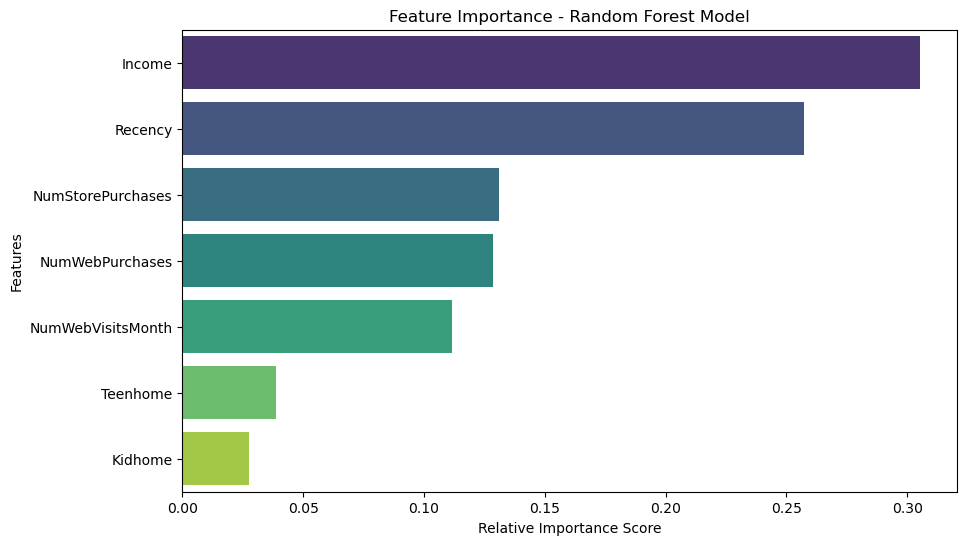

In [28]:

# Select Features
# Including demographics and purchasing habits
features = ['Income', 'Recency', 'NumWebPurchases', 'NumStorePurchases', 
            'NumWebVisitsMonth', 'Kidhome', 'Teenhome']
X = df[features]
y = df['Response']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Get Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = [features[i] for i in indices]

# Plotting the Graph
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=feature_names, palette='viridis')
plt.title('Feature Importance - Random Forest Model')
plt.xlabel('Relative Importance Score')
plt.ylabel('Features')
plt.show()

# visualization

## Based on Education

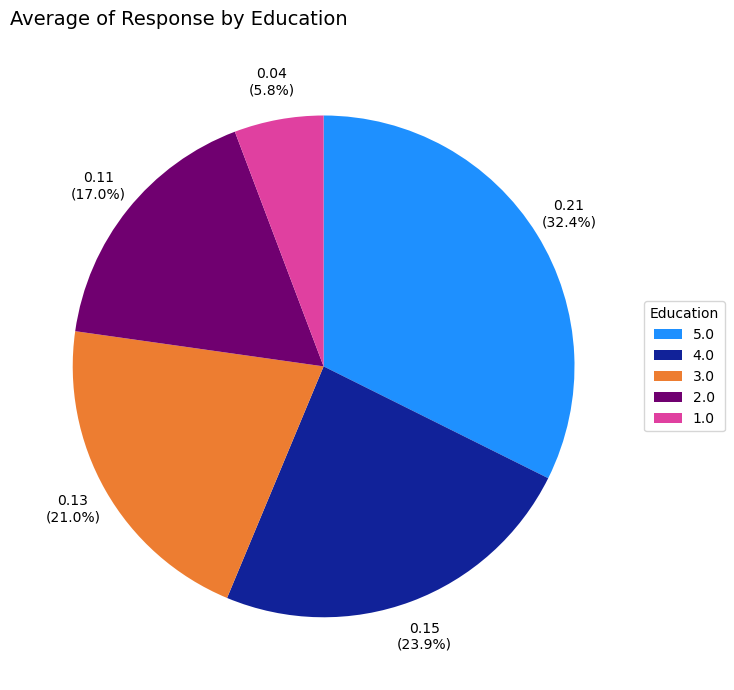

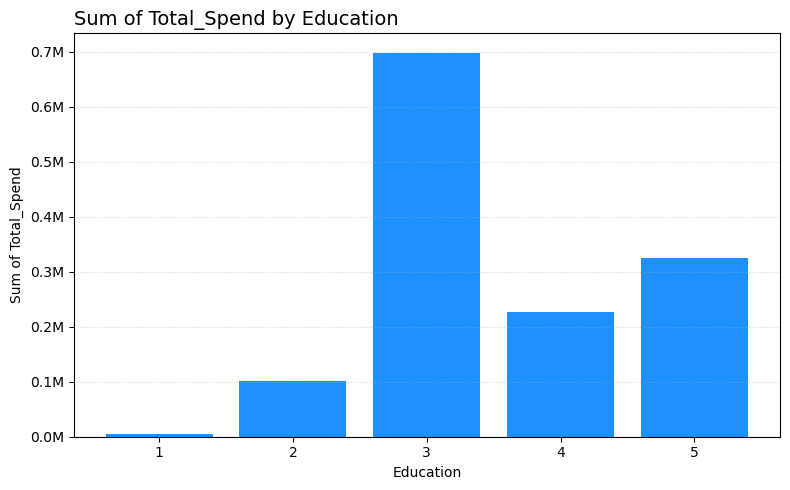

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Ensure Education_Num is mapped correctly (Assumed mapping)
# If your 'Education_Float' is already numeric, this works fine.
df['Education_Num'] = df['Education_Float']

# 2. Calculate Aggregates
avg_response = df.groupby('Education_Num')['Response'].mean().sort_values(ascending=False)
# FIX: Define spend_by_edu which was missing in your snippet
spend_by_edu = df.groupby('Education_Num')['Total_Spend'].sum().sort_values(ascending=False)

# --- PIE CHART ---
plt.figure(figsize=(8, 7))
colors = ['#1E90FF', '#112299', '#ED7D31', '#700070', '#E040A0']

# FIX: Simplified autopct to show the actual mean value and the % contribution
def fmt(pct):
    # Calculate the absolute value from the percentage
    absolute = pct / 100. * values.sum()
    return f'{absolute:.2f}\n({pct:.1f}%)'

labels = avg_response.index
values = avg_response.values

plt.pie(values, labels=None, autopct=fmt, startangle=90, 
        colors=colors, counterclock=False, pctdistance=1.15)

plt.title('Average of Response by Education', loc='left', fontsize=14, pad=20)
plt.legend(labels, title="Education", loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

# --- BAR CHART ---
plt.figure(figsize=(8, 5))

# Use the pre-calculated spend_by_edu
plt.bar(spend_by_edu.index, spend_by_edu.values, color='#1E90FF')

# FIX: Formatting Y-axis to '0.0M'
# Note: If your data is in the millions, x*1e-6 is correct. 
# If data is raw integers, use x/1e6.
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))

plt.title('Sum of Total_Spend by Education', loc='left', fontsize=14)
plt.xlabel('Education')
plt.ylabel('Sum of Total_Spend')
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

## Based on Income

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27432\523262601.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=income_response, x='Income_Group', y='Response', palette='viridis')


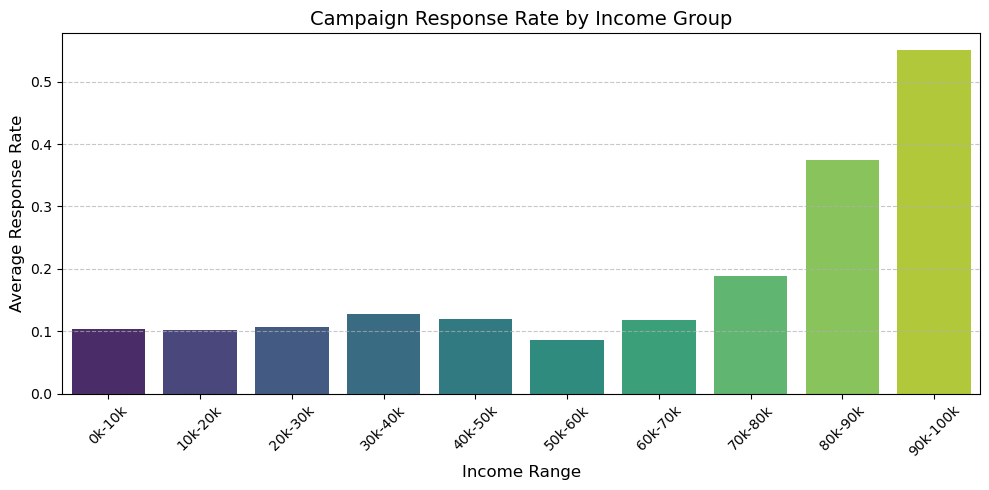

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27432\523262601.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=income_spend, x='Income_Group', y='Total_Spend', palette='magma')


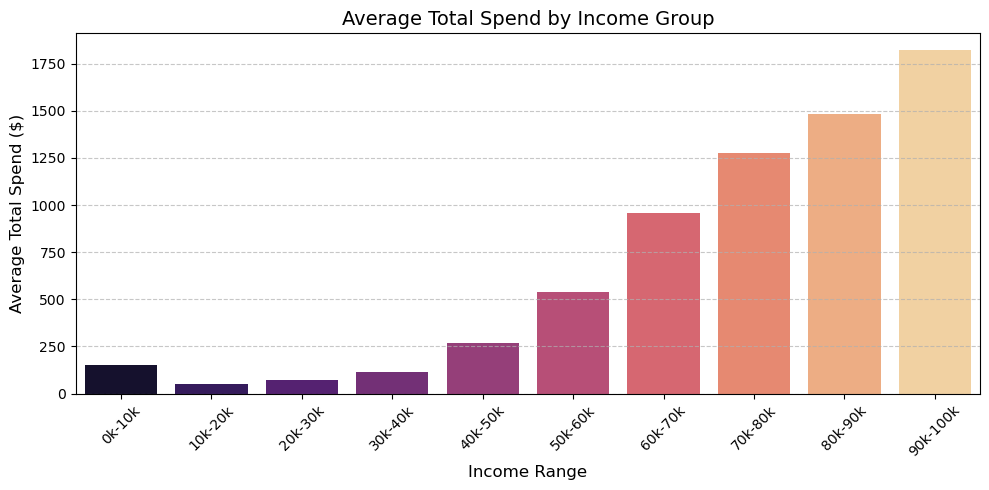

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create Income Bins (0 to 100k)
bins = list(range(0, 110000, 10000))
labels = [f'{i//1000}k-{(i+10000)//1000}k' for i in bins[:-1]]
df['Income_Group'] = pd.cut(df['Income'], bins=bins, labels=labels)

# 2. Calculate Aggregates
# We use observed=False to ensure all bins appear even if they have no data
income_response = df.groupby('Income_Group', observed=False)['Response'].mean().reset_index()
# FIX: Added the missing income_spend calculation
income_spend = df.groupby('Income_Group', observed=False)['Total_Spend'].mean().reset_index()

# --- Plot 1: Campaign Response Rate ---
plt.figure(figsize=(10, 5))
sns.barplot(data=income_response, x='Income_Group', y='Response', palette='viridis')
plt.title('Campaign Response Rate by Income Group', fontsize=14)
plt.xlabel('Income Range', fontsize=12)
plt.ylabel('Average Response Rate', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Plot 2: Average Total Spend ---
plt.figure(figsize=(10, 5))
# FIX: Now using the newly defined income_spend dataframe
sns.barplot(data=income_spend, x='Income_Group', y='Total_Spend', palette='magma')
plt.title('Average Total Spend by Income Group', fontsize=14)
plt.xlabel('Income Range', fontsize=12)
plt.ylabel('Average Total Spend ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Base on kids home

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27432\74883090.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=spend_stats.index, y=spend_stats.values, palette='Blues_d', ax=ax1)


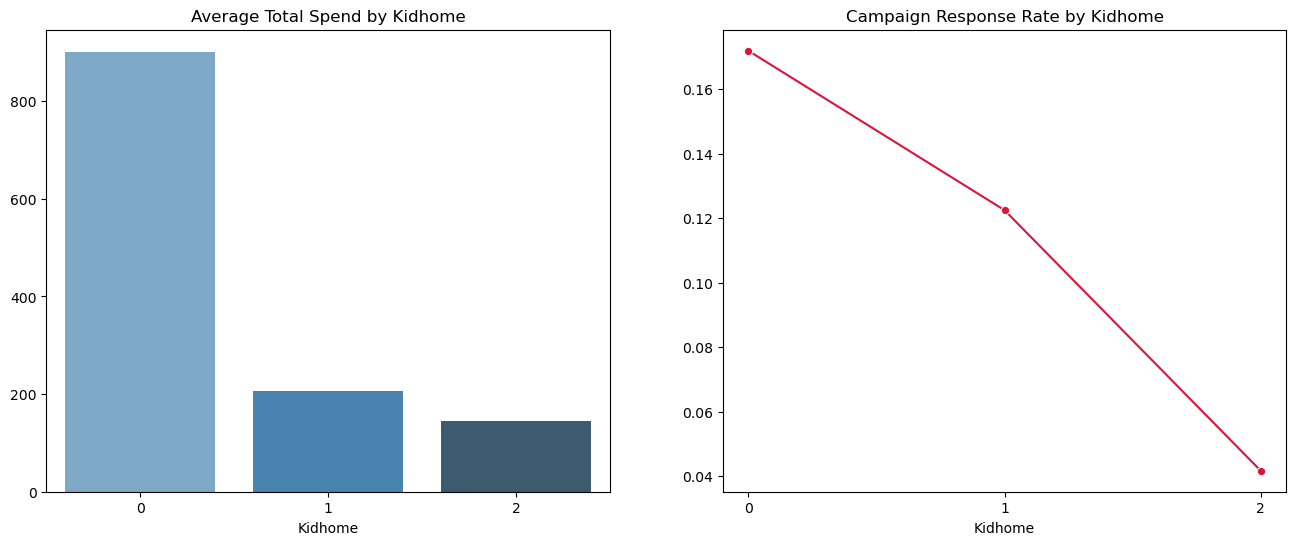

In [33]:
# Calculate Total Spend and Kidhome Stats
df['Total_Spend'] = df['Total_Spend']
spend_stats = df.groupby('Kidhome')['Total_Spend'].mean()
response_stats = df.groupby('Kidhome')['Response'].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Total Spend by Kidhome (Bar Graph)[cite: 1]
sns.barplot(x=spend_stats.index, y=spend_stats.values, palette='Blues_d', ax=ax1)
ax1.set_title('Average Total Spend by Kidhome')

# 2. Response by Kidhome (Line Graph)[cite: 1]
sns.lineplot(x=response_stats.index, y=response_stats.values, marker='o', color='crimson', ax=ax2)
ax2.set_title('Campaign Response Rate by Kidhome')
ax2.set_xticks([0, 1, 2])

plt.show()

## Based on Age

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27432\2449193674.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Age_Group', y='Web_Ratio', palette='viridis', ax=ax1)


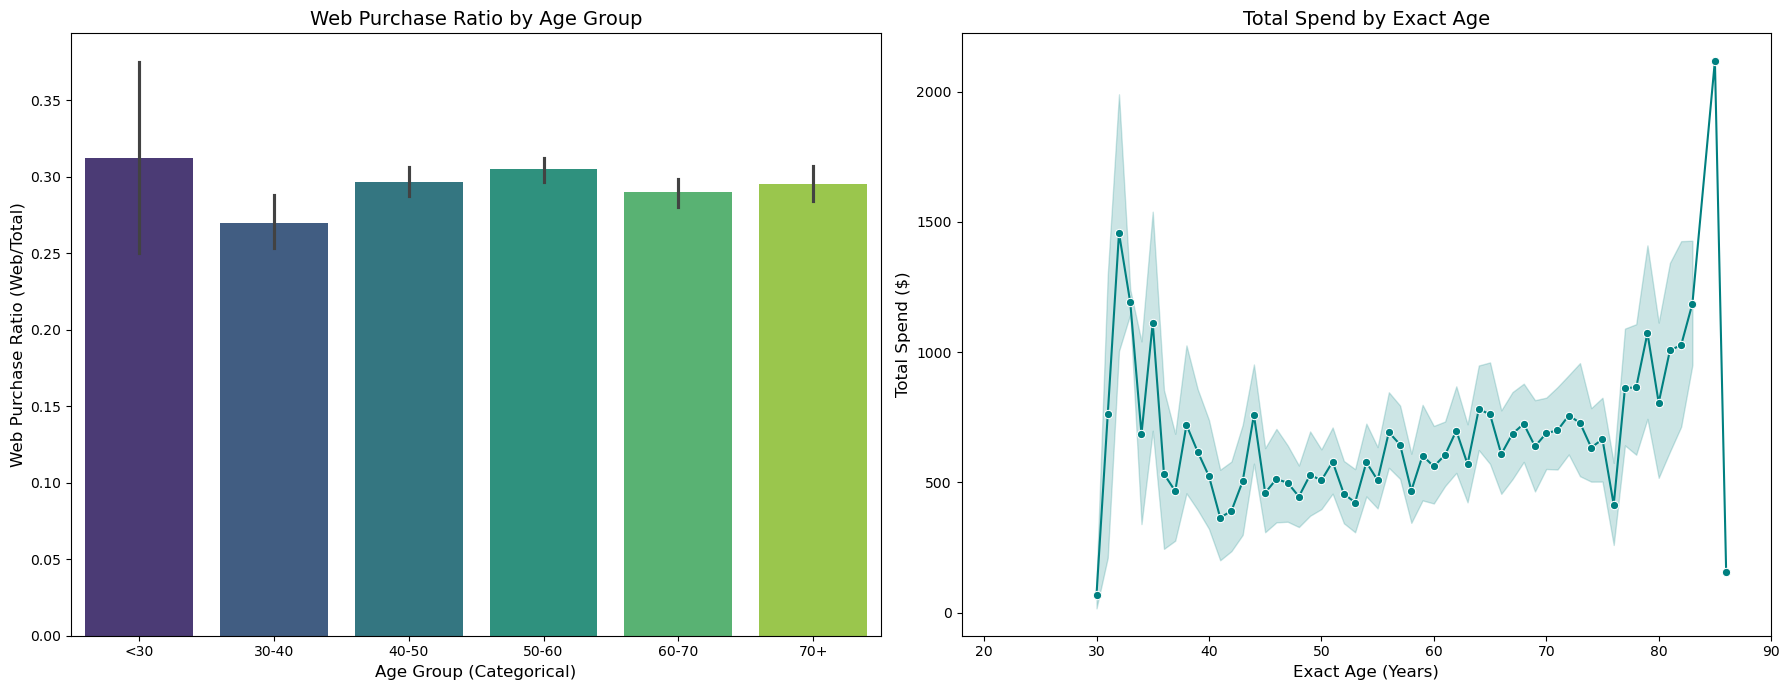

In [35]:
# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- Plot 1: Bar Graph (Web Ratio by Age Group) ---
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 30, 40, 50, 60, 70, 120], 
                         labels=['<30', '30-40', '40-50', '50-60', '60-70', '70+'])

sns.barplot(data=df, x='Age_Group', y='Web_Ratio', palette='viridis', ax=ax1)

# Defining Axis Labels for Plot 1
ax1.set_title('Web Purchase Ratio by Age Group', fontsize=14)
ax1.set_xlabel('Age Group (Categorical)', fontsize=12)
ax1.set_ylabel('Web Purchase Ratio (Web/Total)', fontsize=12)

# --- Plot 2: Line Graph (Total Spend by Exact Age) ---
sns.lineplot(data=df, x='Age', y='Total_Spend', marker='o', color='teal', ax=ax2)
ax2.set_xlim(18, 90) 

# Defining Axis Labels for Plot 2
ax2.set_title('Total Spend by Exact Age', fontsize=14)
ax2.set_xlabel('Exact Age (Years)', fontsize=12)
ax2.set_ylabel('Total Spend ($)', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
final_df=df

In [ ]:
final_df.to_csv("cleaned_data.csv",index=False)

In [ ]:
final_df.to_excel("cleaned_data.xlsx",index=False)